In [1]:
# ============================================================
# SUPPORT VECTOR MACHINE (SVM)
# LINEAR AND NON-LINEAR SVM
# ============================================================
#
# This program is designed for teaching and visualization.
#
# PART A  : Linear SVM
# PART B  : Margin and Support Vectors
# PART C  : Soft-Margin SVM and C
# PART D  : Nonlinear SVM
# PART E  : Polynomial Kernel
# PART F  : RBF Kernel
# PART G  : Effect of gamma
# PART H  : Comparison
#
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.datasets import (
    make_blobs,
    make_circles
)

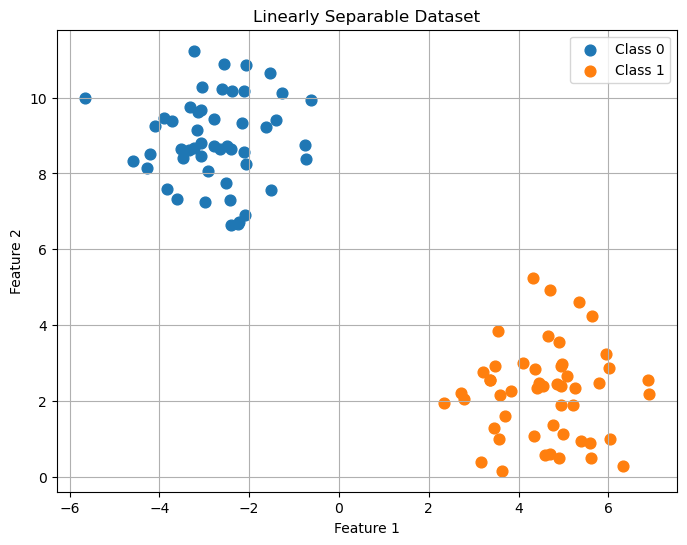

LINEAR SVM PARAMETERS
w1 = 0.28465809342483495
w2 = -0.17755841637632705
b  = 0.6995645425778926

Margin width = 5.961332063232405


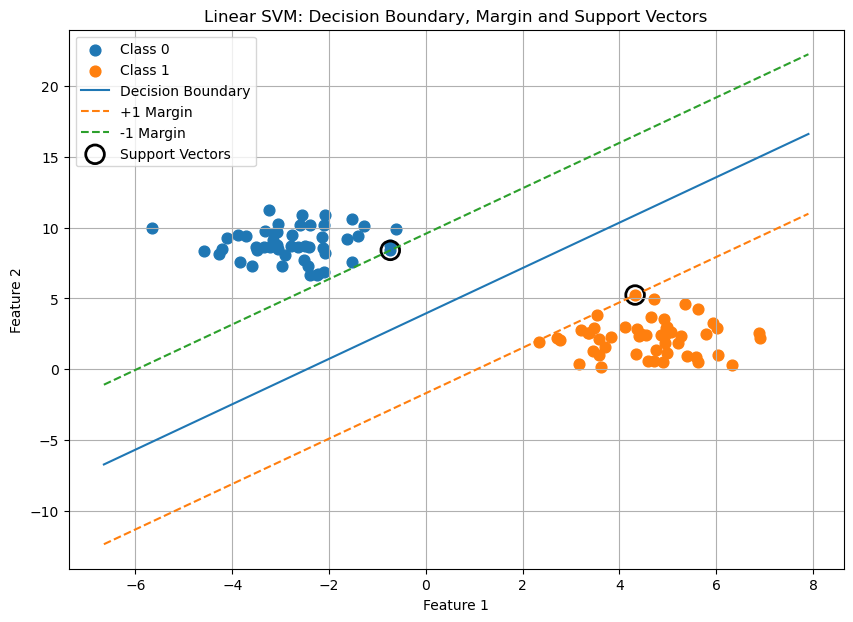


SUPPORT VECTORS
[[-0.73572477  8.39236187]
 [ 4.32229064  5.23737268]]

Number of support vectors: 2

DISTANCE FROM DECISION BOUNDARY
Sample 0 : Distance = 5.185
Sample 1 : Distance = 5.411
Sample 2 : Distance = 5.439
Sample 3 : Distance = 4.61
Sample 4 : Distance = 4.379
Sample 5 : Distance = 5.423
Sample 6 : Distance = 4.734
Sample 7 : Distance = 3.355
Sample 8 : Distance = 4.284
Sample 9 : Distance = 5.473
C = 0.01  | Accuracy = 0.933 | Support vectors = 53
C = 0.1  | Accuracy = 0.933 | Support vectors = 29
C = 1  | Accuracy = 0.94 | Support vectors = 24
C = 10  | Accuracy = 0.933 | Support vectors = 23
C = 100  | Accuracy = 0.933 | Support vectors = 23


In [2]:
# ============================================================
# PART A
# LINEAR SVM
# ============================================================


# ============================================================
# 2. CREATE A LINEARLY SEPARABLE DATASET
# ============================================================
#
# We create two groups of points.
#
# Class 0 → one group
# Class 1 → another group
#
# A straight line can separate the two classes.
#
# ============================================================

X_linear, y_linear = make_blobs(
    n_samples=100,
    centers=2,
    cluster_std=1.2,
    random_state=42
)


# ============================================================
# 3. VISUALIZE ORIGINAL DATA
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_linear[y_linear == 0, 0],
    X_linear[y_linear == 0, 1],
    label="Class 0",
    s=60
)

plt.scatter(
    X_linear[y_linear == 1, 0],
    X_linear[y_linear == 1, 1],
    label="Class 1",
    s=60
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    "Linearly Separable Dataset"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 4. TRAIN LINEAR SVM
# ============================================================
#
# kernel = "linear"
#
# Therefore:
#
#       Decision boundary = linear
#
# ============================================================

linear_svm = SVC(
    kernel="linear",
    C=1.0
)

linear_svm.fit(
    X_linear,
    y_linear
)


# ============================================================
# 5. EXTRACT SVM PARAMETERS
# ============================================================
#
# For a linear SVM:
#
#       w1*x1 + w2*x2 + b = 0
#
# where:
#
#       w = model.coef_
#       b = model.intercept_
#
# ============================================================

w = linear_svm.coef_[0]

b = linear_svm.intercept_[0]


print("==========================================")
print("LINEAR SVM PARAMETERS")
print("==========================================")

print("w1 =", w[0])
print("w2 =", w[1])
print("b  =", b)


# ============================================================
# 6. DECISION FUNCTION
# ============================================================
#
# The SVM calculates:
#
#       f(x) = w^T x + b
#
# If:
#
#       f(x) > 0 → Class 1
#
#       f(x) < 0 → Class 0
#
# ============================================================


def decision_function_manual(X):

    return np.dot(
        X,
        w
    ) + b


# ============================================================
# 7. CALCULATE MARGIN
# ============================================================
#
# SVM decision boundary:
#
#       w.x + b = 0
#
# Margin boundaries:
#
#       w.x + b = +1
#
#       w.x + b = -1
#
# Distance between the two margin boundaries:
#
#       Margin width = 2 / ||w||
#
# ============================================================

weight_norm = np.linalg.norm(w)

margin_width = 2 / weight_norm

print(
    "\nMargin width =",
    margin_width
)


# ============================================================
# 8. FUNCTION TO CALCULATE DECISION BOUNDARY
# ============================================================

def calculate_y(x, w, b, value):

    # Equation:
    #
    #       w1*x + w2*y + b = value
    #
    # Therefore:
    #
    #       y = (value - b - w1*x) / w2

    return (
        value
        - b
        - w[0] * x
    ) / w[1]


# ============================================================
# 9. GET X RANGE FOR PLOTTING
# ============================================================

x_values = np.linspace(
    X_linear[:, 0].min() - 1,
    X_linear[:, 0].max() + 1,
    300
)


# ============================================================
# 10. CALCULATE THREE LINES
# ============================================================
#
# Central line:
#
#       w.x + b = 0
#
# Upper margin:
#
#       w.x + b = +1
#
# Lower margin:
#
#       w.x + b = -1
#
# ============================================================

y_decision = calculate_y(
    x_values,
    w,
    b,
    0
)

y_margin_positive = calculate_y(
    x_values,
    w,
    b,
    1
)

y_margin_negative = calculate_y(
    x_values,
    w,
    b,
    -1
)


# ============================================================
# 11. IDENTIFY SUPPORT VECTORS
# ============================================================
#
# Support vectors are the training samples closest to
# the separating hyperplane.
#
# sklearn stores them in:
#
#       support_vectors_
#
# ============================================================

support_vectors = (
    linear_svm.support_vectors_
)


# ============================================================
# 12. VISUALIZE LINEAR SVM
# ============================================================

plt.figure(figsize=(10, 7))


# Class 0
plt.scatter(
    X_linear[y_linear == 0, 0],
    X_linear[y_linear == 0, 1],
    label="Class 0",
    s=60
)


# Class 1
plt.scatter(
    X_linear[y_linear == 1, 0],
    X_linear[y_linear == 1, 1],
    label="Class 1",
    s=60
)


# Decision boundary
plt.plot(
    x_values,
    y_decision,
    label="Decision Boundary"
)


# Positive margin
plt.plot(
    x_values,
    y_margin_positive,
    linestyle="--",
    label="+1 Margin"
)


# Negative margin
plt.plot(
    x_values,
    y_margin_negative,
    linestyle="--",
    label="-1 Margin"
)


# Support vectors
plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=180,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)


plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title(
    "Linear SVM: Decision Boundary, Margin and Support Vectors"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 13. PRINT SUPPORT VECTORS
# ============================================================

print("\n==========================================")
print("SUPPORT VECTORS")
print("==========================================")

print(
    support_vectors
)

print(
    "\nNumber of support vectors:",
    len(support_vectors)
)


# ============================================================
# 14. CALCULATE DISTANCE FROM HYPERPLANE
# ============================================================
#
# Distance of point x from:
#
#       w.x + b = 0
#
# is:
#
#       |w.x + b| / ||w||
#
# ============================================================

def distance_from_hyperplane(
    X,
    w,
    b
):

    numerator = np.abs(
        np.dot(X, w) + b
    )

    denominator = np.linalg.norm(w)

    return numerator / denominator


distances = distance_from_hyperplane(
    X_linear,
    w,
    b
)


# ============================================================
# 15. DISPLAY DISTANCES
# ============================================================

print("\n==========================================")
print("DISTANCE FROM DECISION BOUNDARY")
print("==========================================")

for i in range(10):

    print(
        "Sample",
        i,
        ": Distance =",
        round(distances[i], 3)
    )


# ============================================================
# PART B
# UNDERSTANDING THE C PARAMETER
# ============================================================


# ============================================================
# 16. CREATE DATA WITH SOME OVERLAP
# ============================================================
#
# Real datasets are often not perfectly separable.
#
# Therefore we create overlapping classes.
#
# ============================================================

X_overlap, y_overlap = make_blobs(
    n_samples=150,
    centers=2,
    cluster_std=2.2,
    random_state=20
)


# ============================================================
# 17. TRAIN SVM WITH DIFFERENT C VALUES
# ============================================================
#
# C controls the penalty for classification errors.
#
# Small C:
#
#       Wider margin
#       More tolerance for errors
#
# Large C:
#
#       Strong penalty for errors
#       Attempts to classify training points more strictly
#
# ============================================================

C_values = [
    0.01,
    0.1,
    1,
    10,
    100
]


# ============================================================
# 18. LOOP THROUGH DIFFERENT C VALUES
# ============================================================

for C in C_values:

    model = SVC(
        kernel="linear",
        C=C
    )

    model.fit(
        X_overlap,
        y_overlap
    )


    predictions = model.predict(
        X_overlap
    )


    accuracy = accuracy_score(
        y_overlap,
        predictions
    )


    print(
        "C =",
        C,
        " | Accuracy =",
        round(accuracy, 3),
        "| Support vectors =",
        len(model.support_vectors_)
    )


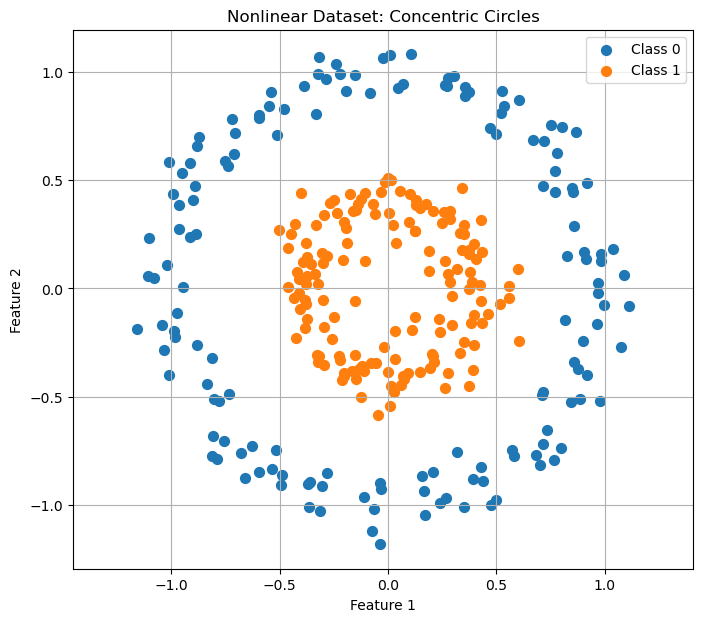

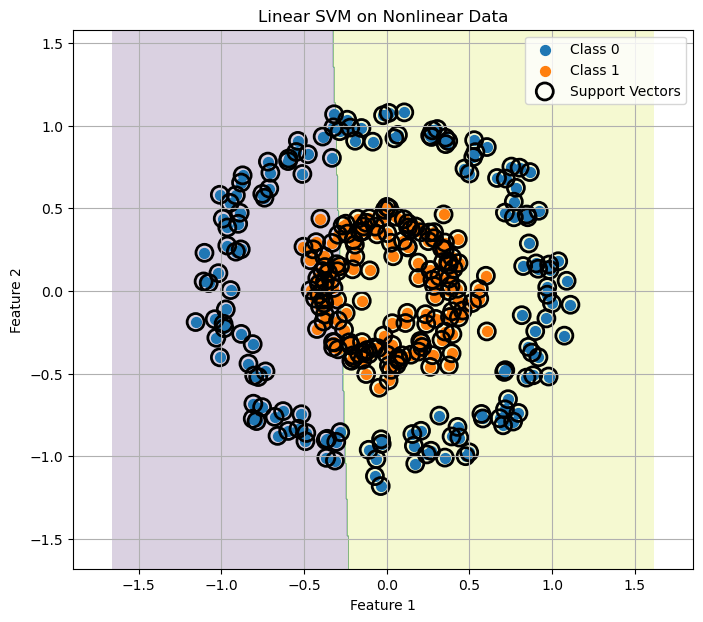

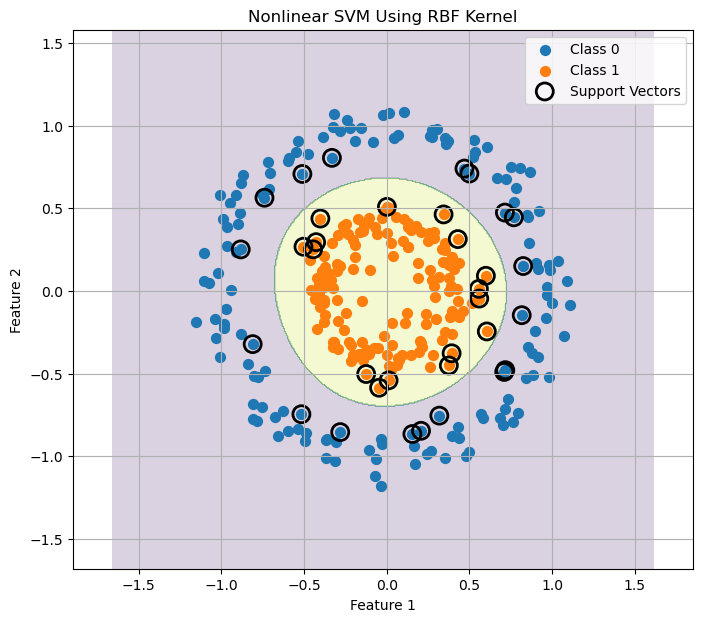

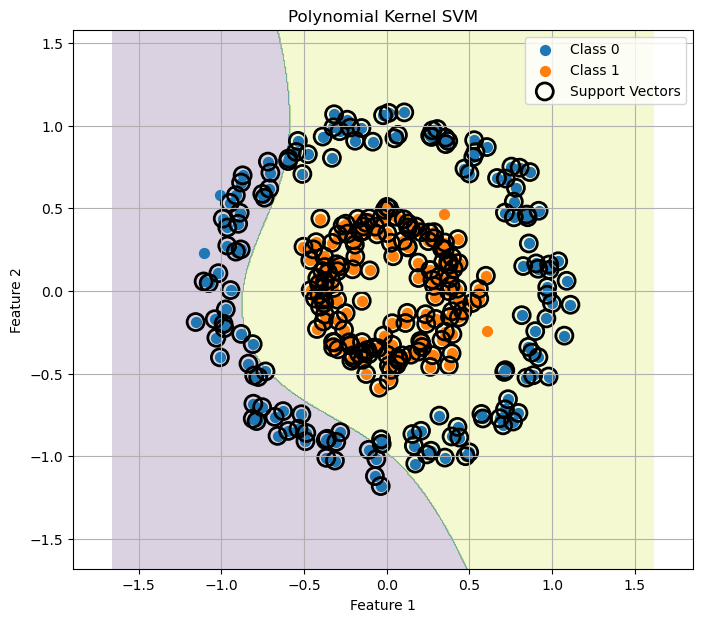

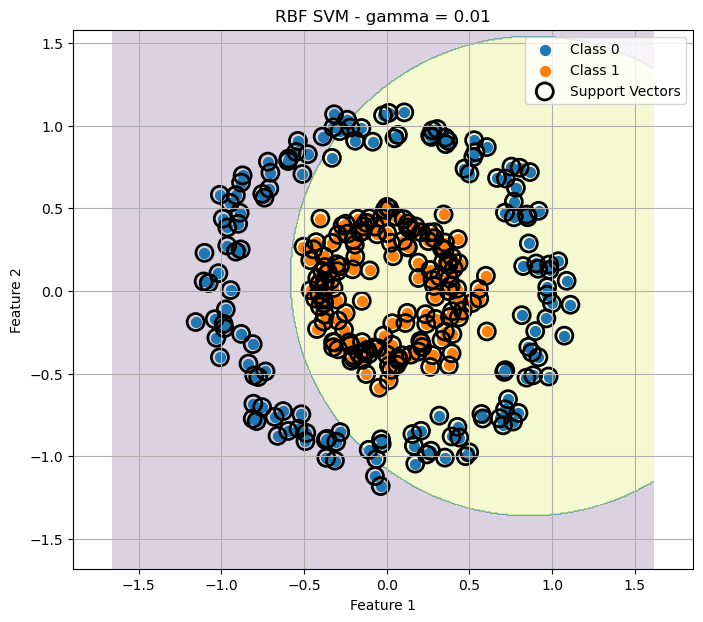

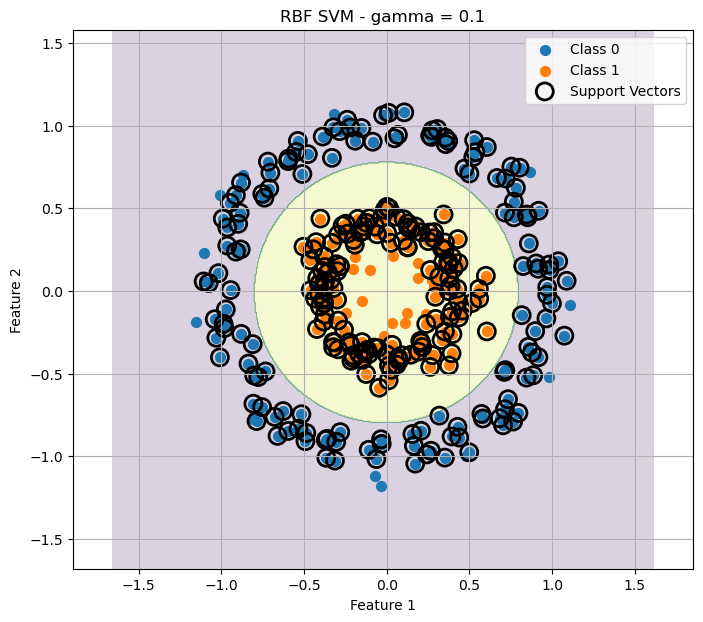

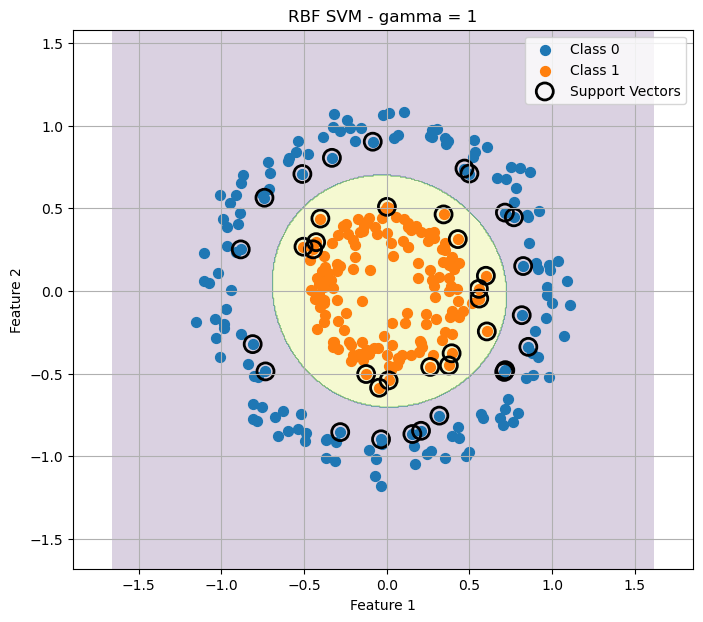

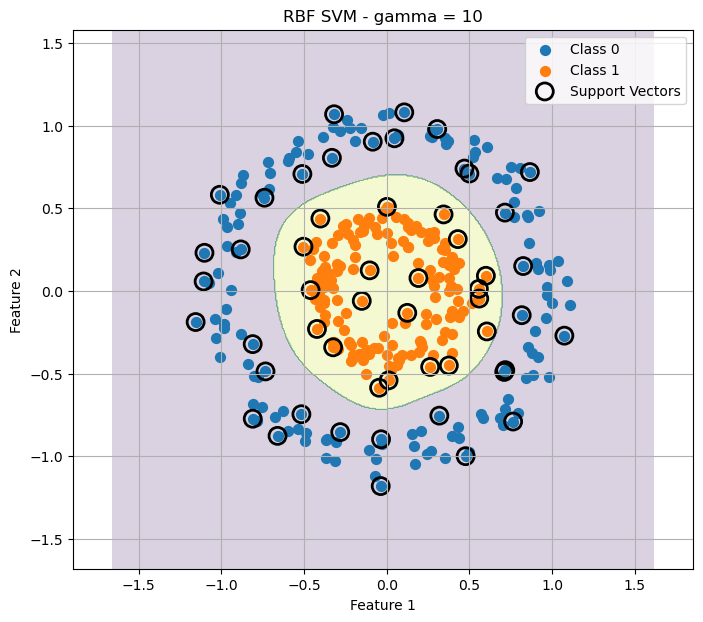


LINEAR SVM PERFORMANCE
Accuracy: 0.5966666666666667
Precision: 0.5714285714285714
Recall: 0.7733333333333333
F1 Score: 0.6572237960339944

RBF SVM PERFORMANCE
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


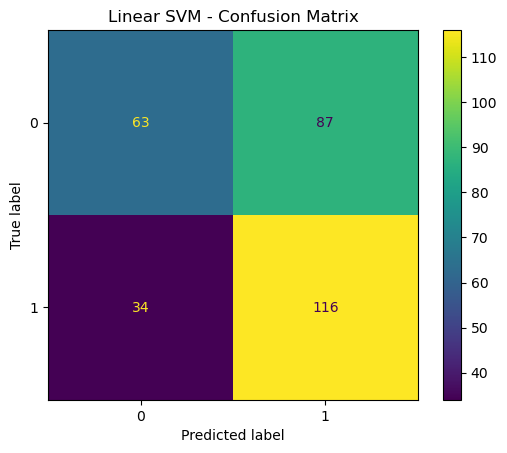

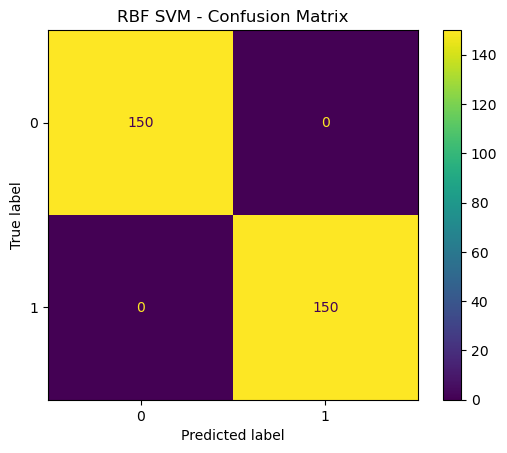

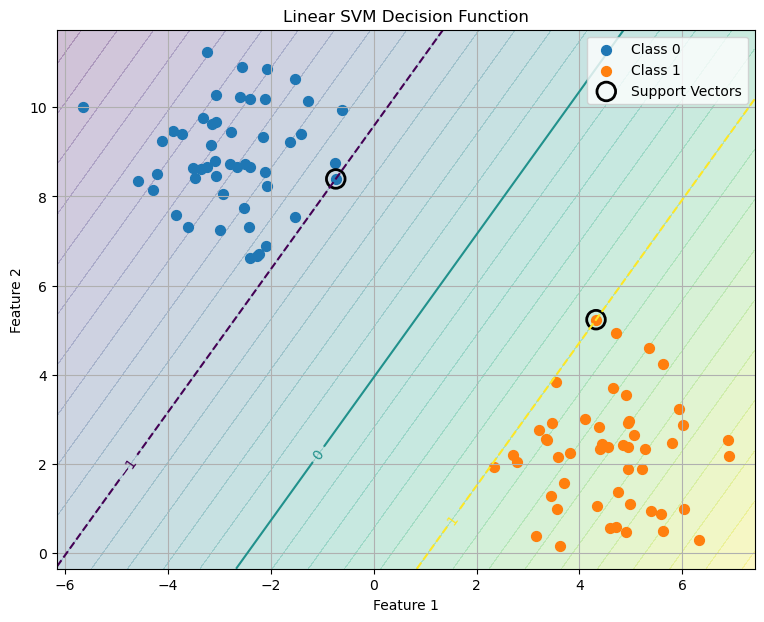

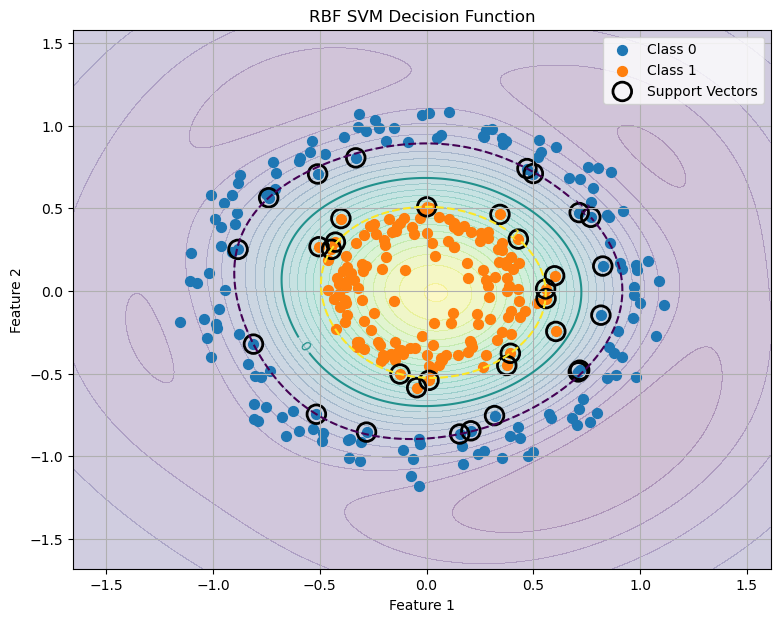


FEATURE TRANSFORMATION
Original feature shape: (300, 2)
Transformed feature shape: (300, 3)

First 5 original samples:
[[-0.14508909  0.36164877]
 [ 0.27718698 -0.3882077 ]
 [ 0.28608472  0.03070876]
 [ 0.85273524  0.44629895]
 [-0.37439214 -0.1425284 ]]

First 5 transformed samples:
[[-0.14508909  0.36164877  0.15184067]
 [ 0.27718698 -0.3882077   0.22753784]
 [ 0.28608472  0.03070876  0.0827875 ]
 [ 0.85273524  0.44629895  0.92634014]
 [-0.37439214 -0.1425284   0.16048382]]

Accuracy after nonlinear feature transformation: 1.0

SVM DEMONSTRATION COMPLETE


In [3]:
# ============================================================
# PART C
# NONLINEAR DATA
# ============================================================


# ============================================================
# 19. CREATE NONLINEAR DATASET
# ============================================================
#
# make_circles creates two concentric circles.
#
# A straight line cannot separate them.
#
# ============================================================

X_circle, y_circle = make_circles(
    n_samples=300,
    factor=0.4,
    noise=0.08,
    random_state=42
)


# ============================================================
# 20. VISUALIZE NONLINEAR DATA
# ============================================================

plt.figure(figsize=(8, 7))

plt.scatter(
    X_circle[y_circle == 0, 0],
    X_circle[y_circle == 0, 1],
    label="Class 0",
    s=50
)

plt.scatter(
    X_circle[y_circle == 1, 0],
    X_circle[y_circle == 1, 1],
    label="Class 1",
    s=50
)

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title(
    "Nonlinear Dataset: Concentric Circles"
)

plt.legend()

plt.axis("equal")

plt.grid(True)

plt.show()


# ============================================================
# 21. TRAIN LINEAR SVM ON NONLINEAR DATA
# ============================================================
#
# This demonstrates the limitation of a linear SVM.
#
# ============================================================

linear_on_circle = SVC(
    kernel="linear",
    C=1
)

linear_on_circle.fit(
    X_circle,
    y_circle
)


# ============================================================
# 22. TRAIN RBF SVM
# ============================================================
#
# RBF = Radial Basis Function
#
# This can produce nonlinear decision boundaries.
#
# ============================================================

rbf_svm = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

rbf_svm.fit(
    X_circle,
    y_circle
)


# ============================================================
# 23. FUNCTION TO PLOT DECISION REGIONS
# ============================================================

def plot_decision_regions(
    model,
    X,
    y,
    title
):

    # Determine plotting limits
    x_min = X[:, 0].min() - 0.5
    x_max = X[:, 0].max() + 0.5

    y_min = X[:, 1].min() - 0.5
    y_max = X[:, 1].max() + 0.5


    # Create grid
    xx, yy = np.meshgrid(
        np.linspace(
            x_min,
            x_max,
            500
        ),
        np.linspace(
            y_min,
            y_max,
            500
        )
    )


    # Convert grid into feature vectors
    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]


    # Predict each grid point
    predictions = model.predict(
        grid
    )


    # Reshape predictions
    predictions = predictions.reshape(
        xx.shape
    )


    # Plot decision regions
    plt.figure(figsize=(8, 7))

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.2
    )


    # Plot class samples
    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        label="Class 0",
        s=50
    )

    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Class 1",
        s=50
    )


    # Plot support vectors
    if hasattr(
        model,
        "support_vectors_"
    ):

        sv = model.support_vectors_

        plt.scatter(
            sv[:, 0],
            sv[:, 1],
            s=150,
            facecolors="none",
            edgecolors="black",
            linewidths=2,
            label="Support Vectors"
        )


    plt.xlabel("Feature 1")

    plt.ylabel("Feature 2")

    plt.title(title)

    plt.legend()

    plt.axis("equal")

    plt.grid(True)

    plt.show()


# ============================================================
# 24. VISUALIZE LINEAR SVM ON NONLINEAR DATA
# ============================================================

plot_decision_regions(
    linear_on_circle,
    X_circle,
    y_circle,
    "Linear SVM on Nonlinear Data"
)


# ============================================================
# 25. VISUALIZE RBF SVM
# ============================================================

plot_decision_regions(
    rbf_svm,
    X_circle,
    y_circle,
    "Nonlinear SVM Using RBF Kernel"
)


# ============================================================
# PART D
# POLYNOMIAL KERNEL
# ============================================================


# ============================================================
# 26. TRAIN POLYNOMIAL KERNEL SVM
# ============================================================
#
# Polynomial kernel:
#
#       K(x,z) = (gamma*x.z + coef0)^degree
#
# It allows SVM to create nonlinear boundaries.
#
# ============================================================

poly_svm = SVC(
    kernel="poly",
    degree=3,
    C=1,
    gamma="scale"
)

poly_svm.fit(
    X_circle,
    y_circle
)


# ============================================================
# 27. VISUALIZE POLYNOMIAL SVM
# ============================================================

plot_decision_regions(
    poly_svm,
    X_circle,
    y_circle,
    "Polynomial Kernel SVM"
)


# ============================================================
# PART E
# EFFECT OF GAMMA
# ============================================================


# ============================================================
# 28. DIFFERENT GAMMA VALUES
# ============================================================
#
# Gamma controls the influence of individual training points.
#
# Small gamma:
#
#       Smooth decision boundary
#       Larger region of influence
#
# Large gamma:
#
#       More localized influence
#       More complex decision boundary
#
# ============================================================

gamma_values = [
    0.01,
    0.1,
    1,
    10
]


# ============================================================
# 29. TRAIN AND VISUALIZE DIFFERENT GAMMA VALUES
# ============================================================

for gamma in gamma_values:

    model = SVC(
        kernel="rbf",
        C=1,
        gamma=gamma
    )


    model.fit(
        X_circle,
        y_circle
    )


    plot_decision_regions(
        model,
        X_circle,
        y_circle,
        "RBF SVM - gamma = " + str(gamma)
    )


# ============================================================
# PART F
# MODEL EVALUATION
# ============================================================


# ============================================================
# 30. EVALUATE LINEAR SVM
# ============================================================

linear_predictions = linear_on_circle.predict(
    X_circle
)


print("\n==========================================")
print("LINEAR SVM PERFORMANCE")
print("==========================================")


print(
    "Accuracy:",
    accuracy_score(
        y_circle,
        linear_predictions
    )
)


print(
    "Precision:",
    precision_score(
        y_circle,
        linear_predictions
    )
)


print(
    "Recall:",
    recall_score(
        y_circle,
        linear_predictions
    )
)


print(
    "F1 Score:",
    f1_score(
        y_circle,
        linear_predictions
    )
)


# ============================================================
# 31. EVALUATE RBF SVM
# ============================================================

rbf_predictions = rbf_svm.predict(
    X_circle
)


print("\n==========================================")
print("RBF SVM PERFORMANCE")
print("==========================================")


print(
    "Accuracy:",
    accuracy_score(
        y_circle,
        rbf_predictions
    )
)


print(
    "Precision:",
    precision_score(
        y_circle,
        rbf_predictions
    )
)


print(
    "Recall:",
    recall_score(
        y_circle,
        rbf_predictions
    )
)


print(
    "F1 Score:",
    f1_score(
        y_circle,
        rbf_predictions
    )
)


# ============================================================
# 32. CONFUSION MATRIX - LINEAR SVM
# ============================================================

cm_linear = confusion_matrix(
    y_circle,
    linear_predictions
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_linear
)

disp.plot()

plt.title(
    "Linear SVM - Confusion Matrix"
)

plt.show()


# ============================================================
# 33. CONFUSION MATRIX - RBF SVM
# ============================================================

cm_rbf = confusion_matrix(
    y_circle,
    rbf_predictions
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rbf
)

disp.plot()

plt.title(
    "RBF SVM - Confusion Matrix"
)

plt.show()


# ============================================================
# PART G
# DECISION FUNCTION VISUALIZATION
# ============================================================


# ============================================================
# 34. VISUALIZE DECISION FUNCTION
# ============================================================
#
# For an SVM:
#
#       decision_function(x)
#
# gives the signed distance-like score from the boundary
# (exact geometric distance requires normalization by ||w||
# for the linear case).
#
# Contours:
#
#       0  → decision boundary
#      +1  → positive margin
#      -1  → negative margin
#
# ============================================================

def plot_decision_function(
    model,
    X,
    y,
    title
):

    x_min = X[:, 0].min() - 0.5
    x_max = X[:, 0].max() + 0.5

    y_min = X[:, 1].min() - 0.5
    y_max = X[:, 1].max() + 0.5


    xx, yy = np.meshgrid(
        np.linspace(
            x_min,
            x_max,
            500
        ),
        np.linspace(
            y_min,
            y_max,
            500
        )
    )


    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]


    decision_values = model.decision_function(
        grid
    )


    decision_values = decision_values.reshape(
        xx.shape
    )


    plt.figure(figsize=(9, 7))


    # Filled decision function
    plt.contourf(
        xx,
        yy,
        decision_values,
        levels=30,
        alpha=0.25
    )


    # Draw decision boundary and margins
    contours = plt.contour(
        xx,
        yy,
        decision_values,
        levels=[-1, 0, 1],
        linestyles=["--", "-", "--"]
    )


    plt.clabel(
        contours,
        inline=True,
        fontsize=10
    )


    # Plot class samples
    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        label="Class 0",
        s=50
    )


    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Class 1",
        s=50
    )


    # Plot support vectors
    sv = model.support_vectors_

    plt.scatter(
        sv[:, 0],
        sv[:, 1],
        s=180,
        facecolors="none",
        edgecolors="black",
        linewidths=2,
        label="Support Vectors"
    )


    plt.xlabel("Feature 1")

    plt.ylabel("Feature 2")

    plt.title(title)

    plt.legend()

    plt.grid(True)

    plt.show()


# ============================================================
# 35. LINEAR SVM DECISION FUNCTION
# ============================================================

plot_decision_function(
    linear_svm,
    X_linear,
    y_linear,
    "Linear SVM Decision Function"
)


# ============================================================
# 36. RBF SVM DECISION FUNCTION
# ============================================================

plot_decision_function(
    rbf_svm,
    X_circle,
    y_circle,
    "RBF SVM Decision Function"
)


# ============================================================
# PART H
# KERNEL CONCEPT
# ============================================================


# ============================================================
# 37. SIMPLE NONLINEAR FEATURE TRANSFORMATION
# ============================================================
#
# Suppose the original feature is:
#
#       x = [x1, x2]
#
# Add a nonlinear feature:
#
#       x3 = x1^2 + x2^2
#
# For concentric circles, points can become easier to
# separate using radial information.
#
# ============================================================

X_transformed = np.column_stack(
    (
        X_circle[:, 0],
        X_circle[:, 1],
        X_circle[:, 0] ** 2
        +
        X_circle[:, 1] ** 2
    )
)


# ============================================================
# 38. DISPLAY ORIGINAL AND TRANSFORMED FEATURES
# ============================================================

print("\n==========================================")
print("FEATURE TRANSFORMATION")
print("==========================================")


print(
    "Original feature shape:",
    X_circle.shape
)


print(
    "Transformed feature shape:",
    X_transformed.shape
)


print(
    "\nFirst 5 original samples:"
)

print(
    X_circle[:5]
)


print(
    "\nFirst 5 transformed samples:"
)

print(
    X_transformed[:5]
)


# ============================================================
# 39. TRAIN LINEAR SVM IN TRANSFORMED SPACE
# ============================================================

linear_transformed_svm = SVC(
    kernel="linear",
    C=1
)


linear_transformed_svm.fit(
    X_transformed,
    y_circle
)


# ============================================================
# 40. ACCURACY AFTER TRANSFORMATION
# ============================================================

transformed_predictions = \
    linear_transformed_svm.predict(
        X_transformed
    )


print(
    "\nAccuracy after nonlinear feature transformation:",
    accuracy_score(
        y_circle,
        transformed_predictions
    )
)


# ============================================================
# END OF PROGRAM
# ============================================================

print("\n==========================================")
print("SVM DEMONSTRATION COMPLETE")
print("==========================================")